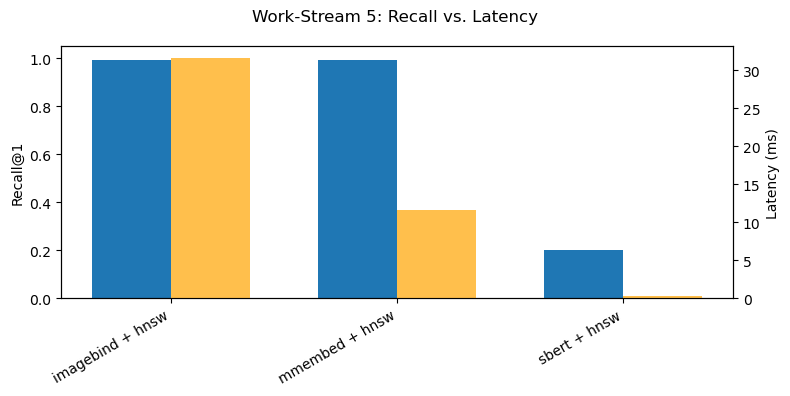

In [2]:
# quick_bench_plot.py
import pandas as pd, glob, numpy as np, matplotlib.pyplot as plt

# 1) Load all of your baseline CSVs (no header row → we assign names)
cols = ["encoder","engine","limit","top_k","recall","lat_ms","embed_ms"]
dfs = []
for f in sorted(glob.glob("logs/baseline_*.tsv")):
    df = pd.read_csv(f, sep="\t", header=None, names=cols)
    df["label"] = df.encoder + " + " + df.engine
    dfs.append(df)
df = pd.concat(dfs, ignore_index=True)

# 2) Extract arrays & x positions
labels  = df["label"].tolist()
recall  = df["recall"].to_numpy()
lat_ms   = df["lat_ms"].to_numpy()
N        = len(labels)
x        = np.arange(N)
width    = 0.35  # bar width

# 3) Plot
fig, ax1 = plt.subplots(figsize=(8,4))
# Recall bars (left)
ax1.bar(x - width/2, recall,  width, label="Recall@1")
ax1.set_ylabel("Recall@1")
ax1.set_ylim(0, 1.05)

# Latency bars (right axis)
ax2 = ax1.twinx()
ax2.bar( x + width/2, lat_ms, width, label="Latency (ms)", color="orange", alpha=0.7)
ax2.set_ylabel("Latency (ms)")

# X ticks
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=30, ha="right")
fig.suptitle("Work-Stream 5: Recall vs. Latency")
fig.tight_layout()
plt.show()
